## Ridge regression def and formula
Ridge regression is a linear regression technique that includes a regularization term to prevent overfitting. The formula for ridge regression is:
J(θ) = (1/2m) * Σ(yᵢ - hθ(xᵢ))² + (λ/2) * Σθⱼ²

Where:
- J(θ) is the cost function to minimize
- m is the number of training examples
- yᵢ is the actual output for the i-th training example
- hθ(xᵢ) is the predicted output for the i-th training example
- λ is the regularization parameter that controls the strength of the regularization

## Lasso regression def and formula
Lasso regression is another linear regression technique that includes a regularization term, but it uses the absolute values of the coefficients instead of their squares. The formula for lasso regression is:
J(θ) = (1/2m) * Σ(yᵢ - hθ(xᵢ))² + λ * Σ|θⱼ|

Where:
- J(θ) is the cost function to minimize
- m is the number of training examples
- yᵢ is the actual output for the i-th training example
- hθ(xᵢ) is the predicted output for the i-th training example
- λ is the regularization parameter that controls the strength of the regularization


## Elastic Regression def and formula
Elastic regression is a regularized regression method that combines the properties of both Lasso (L1) and Ridge (L2) regression. It is used to prevent overfitting and improve the generalization of the model by adding a penalty term to the loss function.
The formula for elastic regression is as follows:
L(β) = RSS + λ1 * ||β||1 + λ2 * ||β||2^2

Where:
- L(β) is the loss function that we want to minimize.
- RSS (Residual Sum of Squares) is the sum of squared differences between the observed and predicted values.
- λ1 is the regularization parameter for the L1 penalty (Lasso).
- λ2 is the regularization parameter for the L2 penalty (Ridge).

The elastic regression model can be expressed as:
y = Xβ + ε

Where:
- y is the vector of observed values.
- X is the matrix of input features.
- β is the vector of coefficients to be estimated.
- ε is the error term.


c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.694766913569626e-21.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


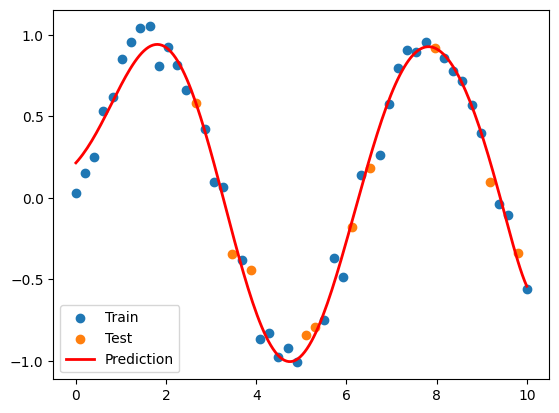

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


def ridge_poly_regression(degree):

    regression = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("ridge", Ridge(alpha=1.0))
    ])

    X = np.linspace(0, 10, 50).reshape(-1, 1)

    Y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=50)

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    regression.fit(X_train, Y_train)

    X_new = np.linspace(0, 10, 200).reshape(-1, 1)

    y_pred = regression.predict(X_new)

    plt.scatter(X_train, Y_train, label="Train")
    plt.scatter(X_test, Y_test, label="Test")
    plt.plot(X_new, y_pred, "r", linewidth=2, label="Prediction")

    plt.legend()
    plt.show()


ridge_poly_regression(10)

c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.567e+00, tolerance: 1.810e-03
  model = cd_fast.enet_coordinate_descent(


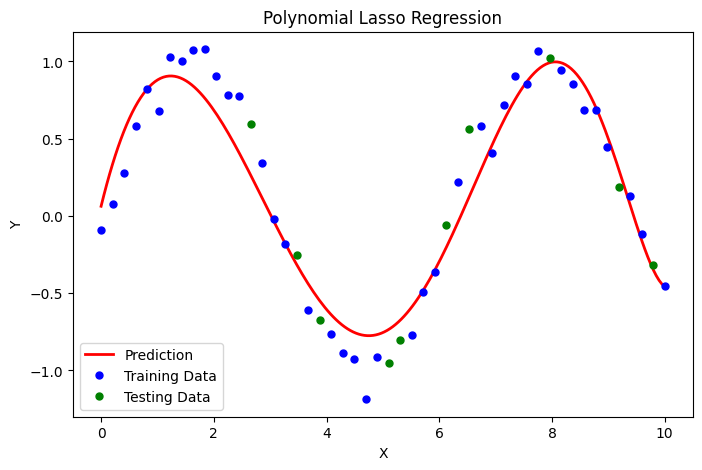

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


def lasso_poly_regression(degree):

    regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("lasso_regression", Lasso(alpha=0.01, max_iter=10000))
    ])

    # Create sample data
    X = np.linspace(0, 10, 50).reshape(-1, 1)

    Y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=50)

    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # Train model
    regression.fit(X_train, Y_train)

    # Predictions
    X_new = np.linspace(0, 10, 200).reshape(-1, 1)

    y_pred = regression.predict(X_new)

    # Plot
    plt.figure(figsize=(8, 5))

    plt.plot(X_new, y_pred, "r-", linewidth=2, label="Prediction")

    plt.plot(X_train, Y_train, "b.", markersize=10, label="Training Data")

    plt.plot(X_test, Y_test, "g.", markersize=10, label="Testing Data")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Polynomial Lasso Regression")
    plt.legend()

    plt.show()


lasso_poly_regression(10)

c:\Users\bharg\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.188e+00, tolerance: 1.750e-03
  model = cd_fast.enet_coordinate_descent(


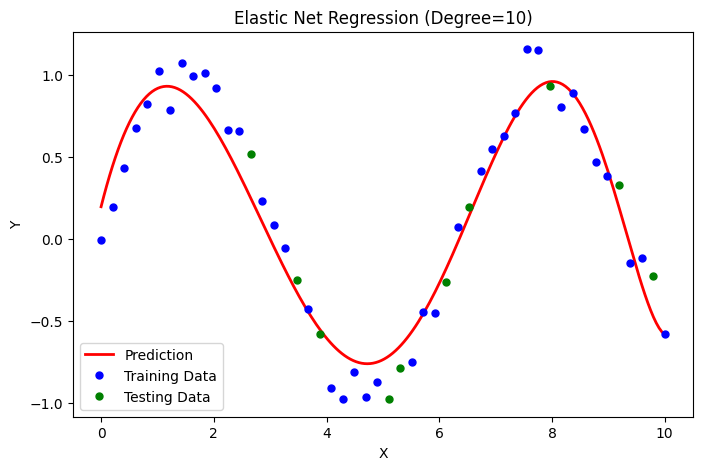

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt


def elastic_poly_regression(degree):

    regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("elastic_net", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000
        ))
    ])

    # Generate sample data
    X = np.linspace(0, 10, 50).reshape(-1, 1)
    Y = np.sin(X).ravel() + np.random.normal(scale=0.1, size=50)

    # Train-test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=42
    )

    # Train
    regression.fit(X_train, Y_train)

    # Predict
    X_new = np.linspace(0, 10, 200).reshape(-1, 1)
    y_pred = regression.predict(X_new)

    # Plot
    plt.figure(figsize=(8, 5))

    plt.plot(X_new, y_pred, "r-", linewidth=2, label="Prediction")
    plt.plot(X_train, Y_train, "b.", markersize=10, label="Training Data")
    plt.plot(X_test, Y_test, "g.", markersize=10, label="Testing Data")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Elastic Net Regression (Degree={degree})")
    plt.legend()
    plt.show()


elastic_poly_regression(10)

In [ ]:
#